# Sesión 7 · Mapas del Perú

Una tabla con 475 distritos no se puede leer. Un mapa sí.

Hoy pasamos de la tabla de dengue a un mapa interactivo que se puede publicar.
El paso difícil no es dibujar: es **cruzar** los datos con las fronteras.

In [1]:
import pandas as pd
import geopandas as gpd

## 1. Un GeoDataFrame es un DataFrame con una columna de formas

Todo lo de pandas funciona igual. La única novedad es la columna `geometry`.

In [2]:
distritos = gpd.read_file("../../data/07-mapas/distritos_peru.geojson")
distritos.head()

,ubigeo,departamento,provincia,distrito,geometry
0,060504,CAJAMARCA,CONTUMAZA,GUZMANGO,"POLYGON ((-78.91578 -7.32085, -78.90743 -7.328..."
1,061105,CAJAMARCA,SAN MIGUEL,EL PRADO,"POLYGON ((-79.01679 -6.96945, -79.00984 -6.974..."
2,061109,CAJAMARCA,SAN MIGUEL,NIEPOS,"POLYGON ((-79.21909 -6.85169, -79.20812 -6.853..."
3,061110,CAJAMARCA,SAN MIGUEL,SAN GREGORIO,"POLYGON ((-79.08233 -7.00544, -79.07553 -7.009..."
4,061203,CAJAMARCA,SAN PABLO,SAN LUIS,"POLYGON ((-78.88319 -7.09565, -78.87211 -7.099..."


In [3]:
distritos.shape

(1874, 5)

### La columna `geometry`

Cada fila guarda el polígono del distrito: la lista de puntos que forman su
frontera.

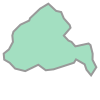

In [4]:
distritos.loc[0, "geometry"]

### El CRS: en qué sistema están esas coordenadas

`EPSG:4326` son grados de latitud y longitud, lo mismo que usa el GPS y lo
que esperan todas las librerías de mapas web. Si tu shapefile viene en otro
sistema, se convierte con `.to_crs(4326)`.

In [5]:
distritos.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Dibujarlo es una línea

<Axes: >

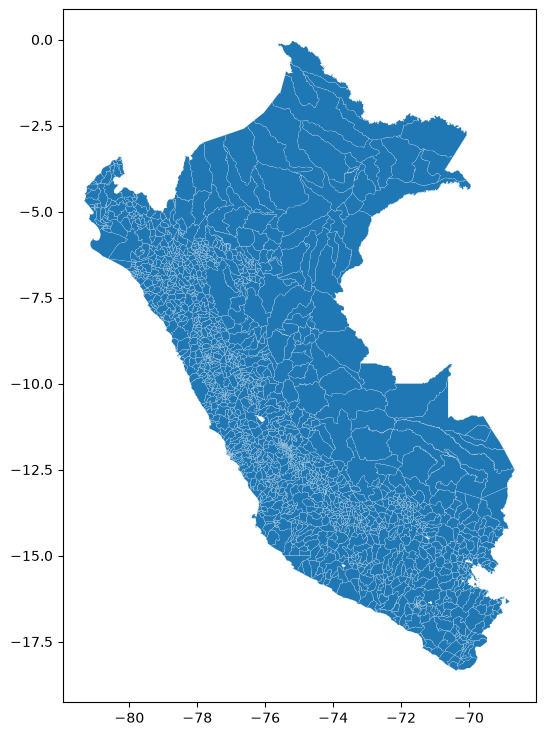

In [6]:
distritos.plot(figsize=(7, 9), edgecolor="white", linewidth=0.1)

## 2. El paso que realmente importa: cruzar

El mapa tiene 1,874 distritos. Nuestra tabla de dengue tiene 475. Hay que
pegarlos por ubigeo, y **el ubigeo tiene que estar escrito igual en los dos
lados**.

In [7]:
tabla = pd.read_csv("../03-pandas/tabla_distritos.csv", dtype={"ubigeo": str})
tabla.head(3)

,ubigeo,departamento,provincia,distrito,casos_dengue,n_establecimientos,camas,casos_por_establecimiento
0,010101,Amazonas,CHACHAPOYAS,CHACHAPOYAS,6.0,12.0,140.0,0.500000
1,010201,Amazonas,BAGUA,BAGUA,949.0,11.0,103.0,86.272727
2,010202,Amazonas,BAGUA,ARAMANGO,49.0,19.0,0.0,2.578947


### Verificar antes de cruzar

Este chequeo de 3 líneas ahorra una hora de confusión.

In [8]:
print("Mapa  :", distritos["ubigeo"].dtype, "| ejemplo:", distritos["ubigeo"].iloc[0])
print("Tabla :", tabla["ubigeo"].dtype, "| ejemplo:", tabla["ubigeo"].iloc[0])
print("Coinciden:", len(set(distritos["ubigeo"]) & set(tabla["ubigeo"])), "de", len(tabla))

Mapa  : object | ejemplo: 060504
Tabla : object | ejemplo: 010101
Coinciden: 475 de 475


### Ahora sí, el merge

Se hace `how="left"` **desde el mapa**, para no perder distritos: los que no
tuvieron dengue deben aparecer en el mapa, en cero.

In [9]:
mapa = distritos.merge(tabla[["ubigeo", "casos_dengue", "n_establecimientos"]],
                       on="ubigeo", how="left")
mapa["casos_dengue"] = mapa["casos_dengue"].fillna(0)
mapa["n_establecimientos"] = mapa["n_establecimientos"].fillna(0)
mapa[["distrito", "departamento", "casos_dengue"]].head()

,distrito,departamento,casos_dengue
0,GUZMANGO,CAJAMARCA,0.0
1,EL PRADO,CAJAMARCA,0.0
2,NIEPOS,CAJAMARCA,0.0
3,SAN GREGORIO,CAJAMARCA,0.0
4,SAN LUIS,CAJAMARCA,0.0


In [10]:
print("Distritos con casos:", (mapa["casos_dengue"] > 0).sum())
print("Total de casos en el mapa:", int(mapa["casos_dengue"].sum()))
print("Total de casos en la tabla:", int(tabla["casos_dengue"].sum()))

Distritos con casos: 473
Total de casos en el mapa: 231122
Total de casos en la tabla: 231122


Los dos totales coinciden: el cruce no perdió nada. **Siempre comprobar esto.**

## 3. Coropleta estática

`column` dice qué variable pinta el color.

<Axes: >

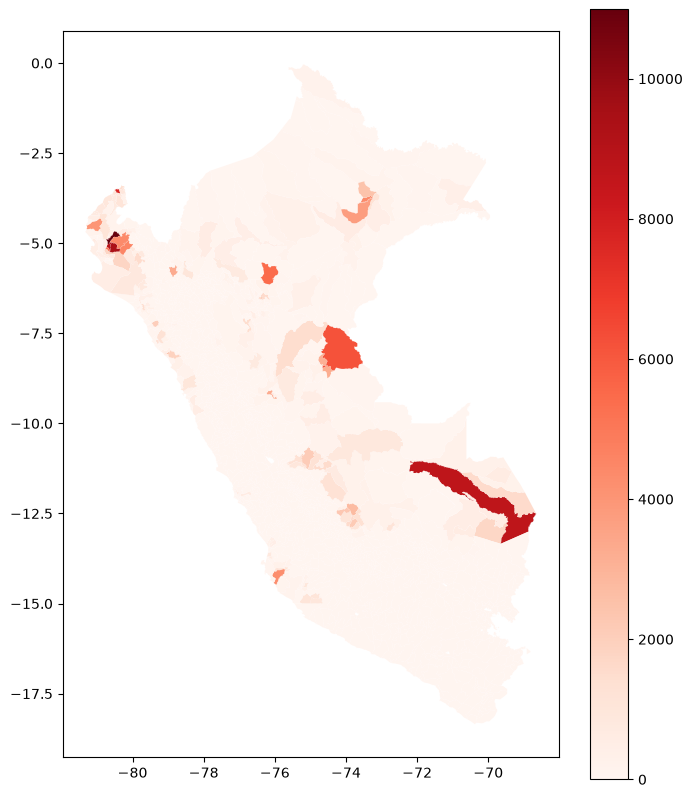

In [11]:
mapa.plot(column="casos_dengue", cmap="Reds", figsize=(8, 10),
          legend=True, edgecolor="white", linewidth=0.05)

### El problema de los valores extremos

Piura tiene tanto que todo lo demás se ve blanco. Con `scheme="quantiles"`
se corta en grupos de igual tamaño y el mapa vuelve a informar.

/Users/alexanderquispe/Documents/GitHub/Diplomado_PUCP/.venv/lib/python3.12/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 6 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


<Axes: >

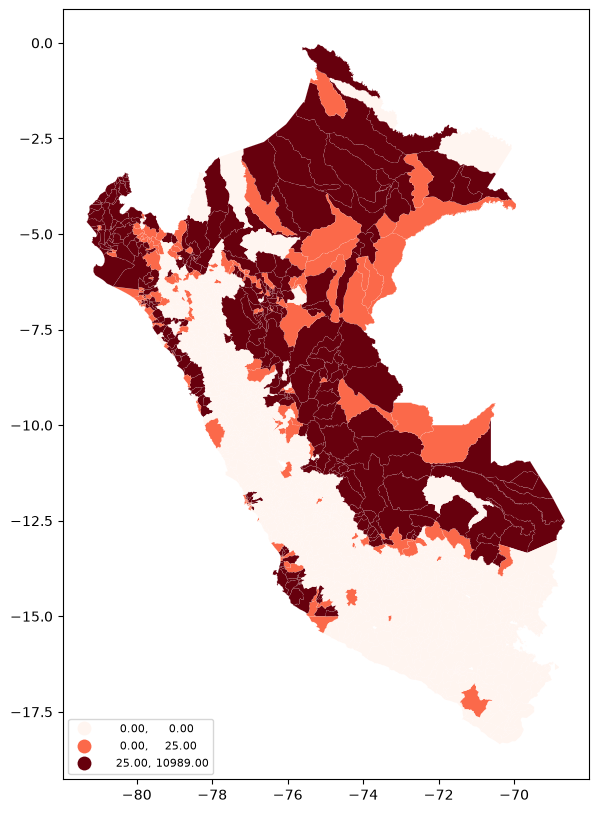

In [12]:
mapa.plot(column="casos_dengue", cmap="Reds", figsize=(8, 10),
          scheme="quantiles", k=6, legend=True,
          edgecolor="white", linewidth=0.05,
          legend_kwds={"loc": "lower left", "fontsize": 8})

## 4. Mapas interactivos con Folium

Lo anterior es una imagen. Folium hace un mapa de verdad: se acerca, se
arrastra, y al pasar el mouse aparece el dato.

In [13]:
import folium

peru = folium.Map(location=[-9.2, -75.0], zoom_start=5, tiles="cartodbpositron")
peru

/Users/alexanderquispe/Documents/GitHub/Diplomado_PUCP/.venv/lib/python3.12/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


### Un marcador

`location` es `[latitud, longitud]` — en ese orden, que es al revés de como
se escriben las coordenadas en muchos otros lados.

In [14]:
m = folium.Map(location=[-5.19, -80.63], zoom_start=11, tiles="cartodbpositron")
folium.Marker(
    location=[-5.19, -80.63],
    popup="Piura: 66,309 casos de dengue 2015-2021",
    tooltip="Clic para ver",
    icon=folium.Icon(color="red", icon="info-sign"),
).add_to(m)
m

## 5. Coropleta interactiva

Para que no pese demasiado, se mapea solo la zona norte, que es donde está
el problema.

In [15]:
norte = mapa[mapa["departamento"].isin(
    ["PIURA", "TUMBES", "LAMBAYEQUE", "LA LIBERTAD"]
)].copy()
norte.shape

(199, 7)

In [ ]:
m = folium.Map(location=[-5.5, -80.0], zoom_start=7, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=norte,
    data=norte,
    columns=["ubigeo", "casos_dengue"],
    key_on="feature.properties.ubigeo",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Casos de dengue 2015-2021",
    bins=[0, 10, 100, 500, 2000, 11000],
).add_to(m)

m

### Agregar el dato al pasar el mouse

Un `Choropleth` solo pinta. Para que muestre información hay que añadir una
capa `GeoJson` encima con un tooltip.

In [ ]:
m = folium.Map(location=[-5.5, -80.0], zoom_start=7, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=norte, data=norte,
    columns=["ubigeo", "casos_dengue"],
    key_on="feature.properties.ubigeo",
    fill_color="YlOrRd", fill_opacity=0.7, line_opacity=0.3,
    legend_name="Casos de dengue 2015-2021",
    bins=[0, 10, 100, 500, 2000, 11000],
).add_to(m)

folium.GeoJson(
    norte,
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["distrito", "provincia", "casos_dengue", "n_establecimientos"],
        aliases=["Distrito:", "Provincia:", "Casos:", "Establecimientos:"],
    ),
).add_to(m)

m

## 6. Puntos: los establecimientos de salud

In [18]:
puntos = pd.read_csv("../../data/07-mapas/establecimientos_coords.csv")
puntos.shape

(15448, 6)

In [19]:
hospitales = puntos[puntos["categoria"].isin(["III-1", "III-2", "II-2"])]
hospitales.shape

(128, 6)

### `CircleMarker` para muchos puntos

Los marcadores con ícono se ponen lentos pasando de unos cientos. Los
círculos aguantan miles.

In [ ]:
m = folium.Map(location=[-9.2, -75.0], zoom_start=5, tiles="cartodbpositron")

for _, fila in hospitales.iterrows():
    folium.CircleMarker(
        location=[fila["latitud"], fila["longitud"]],
        radius=4,
        color="darkblue",
        fill=True,
        fill_opacity=0.7,
        popup=f"{fila['nombre']} ({fila['categoria']})",
    ).add_to(m)

m

### Agrupar puntos cuando son miles

`MarkerCluster` junta los puntos cercanos en un círculo con el número, y los
separa al hacer zoom.

In [ ]:
from folium.plugins import MarkerCluster

m = folium.Map(location=[-9.2, -75.0], zoom_start=5, tiles="cartodbpositron")
cluster = MarkerCluster().add_to(m)

for _, fila in puntos.sample(3000, random_state=1).iterrows():
    folium.CircleMarker(
        location=[fila["latitud"], fila["longitud"]],
        radius=3, color="teal", fill=True,
        popup=fila["nombre"],
    ).add_to(cluster)

m

## 7. Mapa de calor

Muestra dónde se concentra la oferta de salud, sin dibujar cada punto.

In [ ]:
from folium.plugins import HeatMap

m = folium.Map(location=[-9.2, -75.0], zoom_start=5, tiles="cartodbpositron")
HeatMap(
    puntos[["latitud", "longitud"]].values.tolist(),
    radius=8, blur=12,
).add_to(m)
m

## 8. Guardar el mapa

Queda un archivo HTML que se abre en cualquier navegador, sin Python.
Se puede mandar por correo o subir a una web.

In [23]:
mapa_final = folium.Map(location=[-5.5, -80.0], zoom_start=7, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=norte, data=norte,
    columns=["ubigeo", "casos_dengue"],
    key_on="feature.properties.ubigeo",
    fill_color="YlOrRd", fill_opacity=0.7, line_opacity=0.3,
    legend_name="Casos de dengue 2015-2021",
    bins=[0, 10, 100, 500, 2000, 11000],
).add_to(mapa_final)

folium.GeoJson(
    norte,
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["distrito", "casos_dengue"],
        aliases=["Distrito:", "Casos:"],
    ),
).add_to(mapa_final)

for _, fila in hospitales[hospitales["diresa"].str.contains("PIURA|TUMBES", na=False)].iterrows():
    folium.CircleMarker(
        location=[fila["latitud"], fila["longitud"]],
        radius=5, color="darkblue", fill=True, fill_opacity=0.9,
        popup=fila["nombre"],
    ).add_to(mapa_final)

mapa_final.save("mapa_dengue_norte.html")
print("Guardado: mapa_dengue_norte.html")

Guardado: mapa_dengue_norte.html


/Users/alexanderquispe/Documents/GitHub/Diplomado_PUCP/.venv/lib/python3.12/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


### Guardar también la base cruzada, para el dashboard

In [24]:
mapa[["ubigeo", "departamento", "provincia", "distrito",
      "casos_dengue", "n_establecimientos"]].to_csv("distritos_con_datos.csv", index=False)
print("Listo")

Listo


---
## Lo que hicimos

| Paso | Código |
|---|---|
| Cargar fronteras | `gpd.read_file("archivo.geojson")` |
| Ver el sistema | `.crs` |
| Convertir sistema | `.to_crs(4326)` |
| Verificar el cruce | `set(a) & set(b)` antes del merge |
| Cruzar | `.merge(tabla, on="ubigeo", how="left")` |
| Mapa estático | `.plot(column=, cmap=, scheme="quantiles")` |
| Mapa interactivo | `folium.Map(location=[lat, lon], zoom_start=)` |
| Pintar por valor | `folium.Choropleth(...)` |
| Dato al pasar mouse | `folium.GeoJson(tooltip=GeoJsonTooltip(...))` |
| Muchos puntos | `folium.CircleMarker`, `MarkerCluster` |
| Concentración | `HeatMap` |
| Guardar | `m.save("mapa.html")` |

### Lo único que hay que recordar

1. **Folium quiere `[latitud, longitud]`**, en ese orden.
2. **El ubigeo debe ser texto de 6 dígitos en ambas tablas.** Es la causa del
   90% de los mapas que salen en blanco.
3. **Compara los totales después del merge.** Si no cuadran, el mapa miente.